In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

In [2]:
df = pd.read_excel('C://Users//amogh//Documents//GED_EDA_Project//data//processed//6.candidates_cleaned.xlsx')
df.head(10)

,CANDIDATE_ID,avg_score,pass_rate,college_ready_rate,total_attempts,avg_retakes,credential_earned,score_math,score_science,score_reasoning,...,census_region,race_category,gender_label,language_label,income_label,edlevel_label,testing_reason_label,school_incomplete_label,enrollment_label,completeness
0,3642289,136.250000,0.000000,0.000000,4,1.000000,0,138.0,NaN,134.500000,...,South,Black Non-Hispanic,Female,English,Unknown,11th Grade,Personal,Personal & Academic,Unknown,1.0
1,3718315,160.500000,1.000000,0.250000,8,1.000000,1,157.5,158.0,164.000000,...,South,Declined,Decline,English,Under $5K,11th Grade,Personal,Personal,Credentialed,1.0
2,4441930,145.600000,0.800000,0.000000,5,0.250000,1,142.0,148.0,147.000000,...,Midwest,White Non-Hispanic,Male,English,"$5K-$9,999",12th Grade,Work,Personal,Unknown,1.0
3,4508684,163.000000,1.000000,0.600000,5,0.250000,1,163.5,166.0,165.000000,...,South,Hispanic,Male,English,Under $5K,9th Grade,Education,Personal,Unknown,1.0
4,4532273,148.125000,0.875000,0.000000,8,1.000000,1,140.5,155.5,147.500000,...,Midwest,White Non-Hispanic,Female,English,"$5K-$9,999",12th Grade,Personal,Personal,Unknown,1.0
5,4637770,126.000000,0.000000,0.000000,1,0.000000,0,NaN,NaN,126.000000,...,South,Black Non-Hispanic,Female,English,Unknown,12th Grade,Work,Personal,Interested,1.0
6,4725911,150.222222,0.777778,0.111111,9,1.250000,1,154.5,139.0,161.000000,...,South,White Non-Hispanic,Female,English,Unknown,10th Grade,Personal,Personal & Academic,Unknown,1.0
7,4778985,148.714286,0.714286,0.000000,7,1.333333,0,NaN,146.5,151.333333,...,South,Hispanic,Female,English,Unknown,9th Grade,Personal,Personal,Interested,1.0
8,4958811,140.250000,0.250000,0.000000,8,1.000000,0,136.5,143.5,137.666667,...,South,Black Non-Hispanic,Female,English,Unknown,11th Grade,Education,Personal,Interested,1.0
9,5029854,165.250000,1.000000,0.250000,4,0.000000,0,183.0,159.0,157.000000,...,Midwest,White Non-Hispanic,Male,English,"$20K-$29,999",12th Grade,Education,Personal,Unknown,1.0


In [3]:
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
COLORS     = sns.color_palette("muted")
PASS_COLOR = "#4CAF50"
FAIL_COLOR = "#E57373"

In [6]:
df.columns

Index(['CANDIDATE_ID', 'avg_score', 'pass_rate', 'college_ready_rate',
       'total_attempts', 'avg_retakes', 'credential_earned', 'score_math',
       'score_science', 'score_reasoning', 'score_social_studies',
       'pct_online', 'used_ged_ready', 'has_prep_center', 'studied_for_ged',
       'testing_reason', 'school_incomplete_reason', 'enrollment_status',
       'study_adult_ed_class', 'study_books', 'study_online_video', 'gender',
       'language_code', 'last_year_income', 'highest_grade', 'ethnicity',
       'race_white', 'race_black', 'race_asian', 'race_native', 'race_pacific',
       'race_declined', 'race_none', 'birth_year', 'c_state', 'age',
       'census_region', 'race_category', 'gender_label', 'language_label',
       'income_label', 'edlevel_label', 'testing_reason_label',
       'school_incomplete_label', 'enrollment_label', 'completeness'],
      dtype='object')

In [18]:
total_students = 3697
total_ged_ready = len(df[df['used_ged_ready']==1])
#attempted_one = df[['score_math','score_science','score_reasoning','score_social_studies', 'used_ged_ready']].notna().any(axis=1).sum()
attempted_one_official = df[['score_math','score_science','score_reasoning','score_social_studies']].notna().any(axis=1).sum()
attempted_all = df[['score_math', 'score_science', 'score_reasoning', 'score_social_studies']].notna().all(axis=1).sum()
credentialed_students = len(df[df['credential_earned']==1])
#passed_all = ((df['score_math'] >= 145) & (df['score_science'] >= 145) & (df['score_reasoning'] >= 145) &(df['score_social_studies'] >= 145)).sum()

print(f'Total Students: {total_students}')
#print(f'No. of students enrolled: {attempted_one}')
print(f'No. of students taking GED Ready: {total_ged_ready}')
print(f'No. of students taking at least one official GED test: {attempted_one_official}')
print(f'No. of students taking all GED tests: {attempted_all}')
#print(f'No. of students passing all GED tests: {passed_all}')
print(f'No. of students earning GED credentials: {credentialed_students}')

# Enrollment Rate = 100%
official_exam_participation_rate = round(attempted_one_official*100/total_students, 2)
full_participation_rate = round(attempted_all*100/total_students, 2)
completion_rate = round(credentialed_students*100/total_students, 2)

print(f'Offical Exam Participation Rate: {official_exam_participation_rate}%')
print(f'Completion Rate: {completion_rate}%')

Total Students: 3697
No. of students taking GED Ready: 2786
No. of students taking at least one official GED test: 3624
No. of students taking all GED tests: 2270
No. of students earning GED credentials: 1534
Offical Exam Participation Rate: 98.03%
Completion Rate: 41.49%


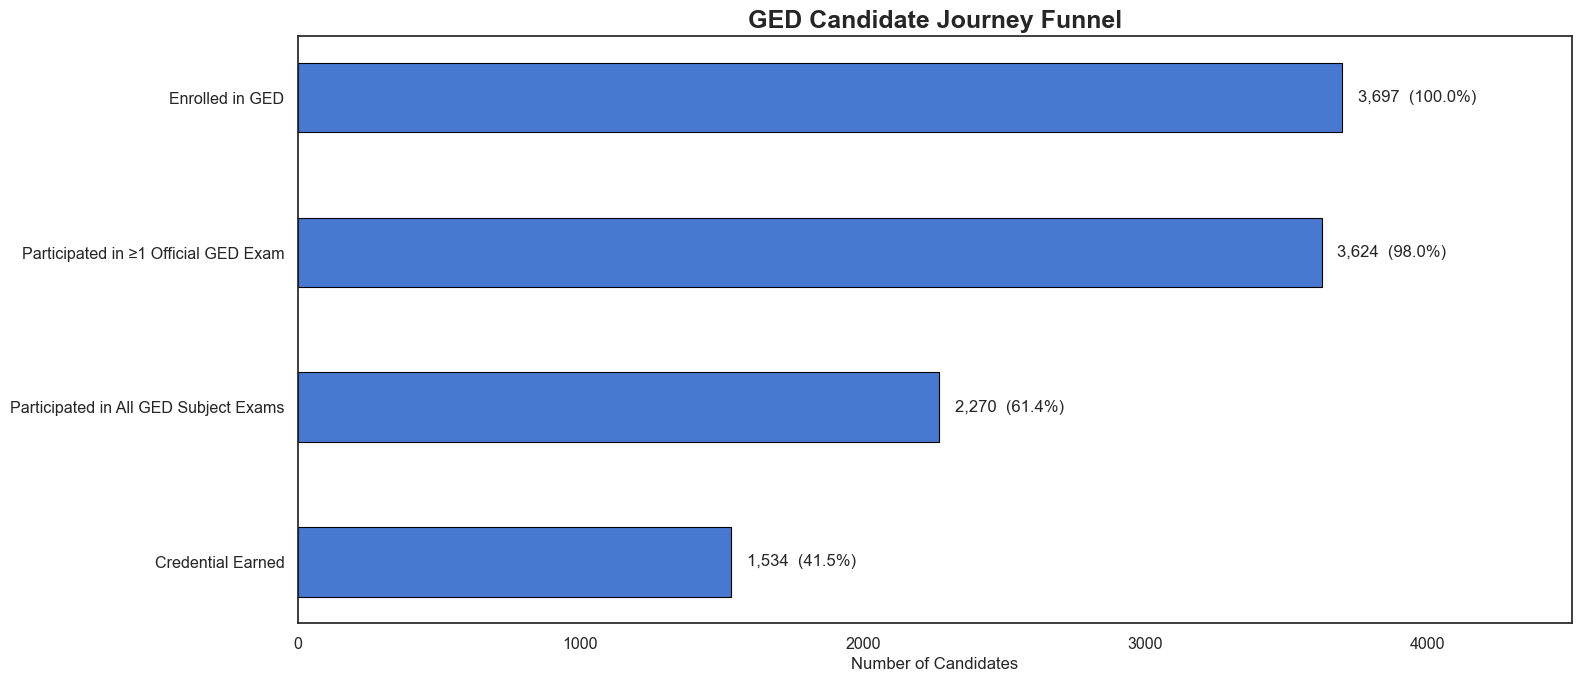

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white", palette="muted", font_scale=1.05)
COLORS     = sns.color_palette("muted")
PASS_COLOR = "#4CAF50"
FAIL_COLOR = "#E57373"

stages = [
    "Enrolled in GED",
    "Participated in ≥1 Official GED Exam",
    "Participated in All GED Subject Exams",
    "Credential Earned"
]
values = [total_students, attempted_one_official, attempted_all, credentialed_students]
percentages = [v / total_students * 100 for v in values]

stages = stages[::-1]
values = values[::-1]
percentages = percentages[::-1]

plt.figure(figsize=(16, 7))  # wider figure

bar_height = 0.45
bars = plt.barh(
    stages,
    values,
    height=bar_height,
    color=COLORS[0],
    edgecolor="black",
    linewidth=0.8
)

for i, (v, pct) in enumerate(zip(values, percentages)):
    label = f"{v:,}  ({pct:.1f}%)"
    plt.text(
        v + total_students * 0.015,
        i,
        label,
        va='center',
        fontsize=12
    )

plt.title("GED Candidate Journey Funnel", fontsize=18, weight='bold')
plt.xlabel("Number of Candidates", fontsize=12)
plt.grid(False)

# Extend x-axis so labels fit inside the frame
plt.xlim(0, total_students * 1.22)

plt.tight_layout()  # no rect needed anymore
plt.show()

The above graph shows a sharp drop-off between "Participated in All GED Subject Exams" (61.4%) and "Credential Earned" (41.5%) : ~20-point gap. 

This hints that completing exams doesn't guarantee passing, which our clusters later explain: Clusters 3 and 4 are the candidates who fell into that gap, with lower avg scores (146 and 145) and 0% credential rates despite exam participation.

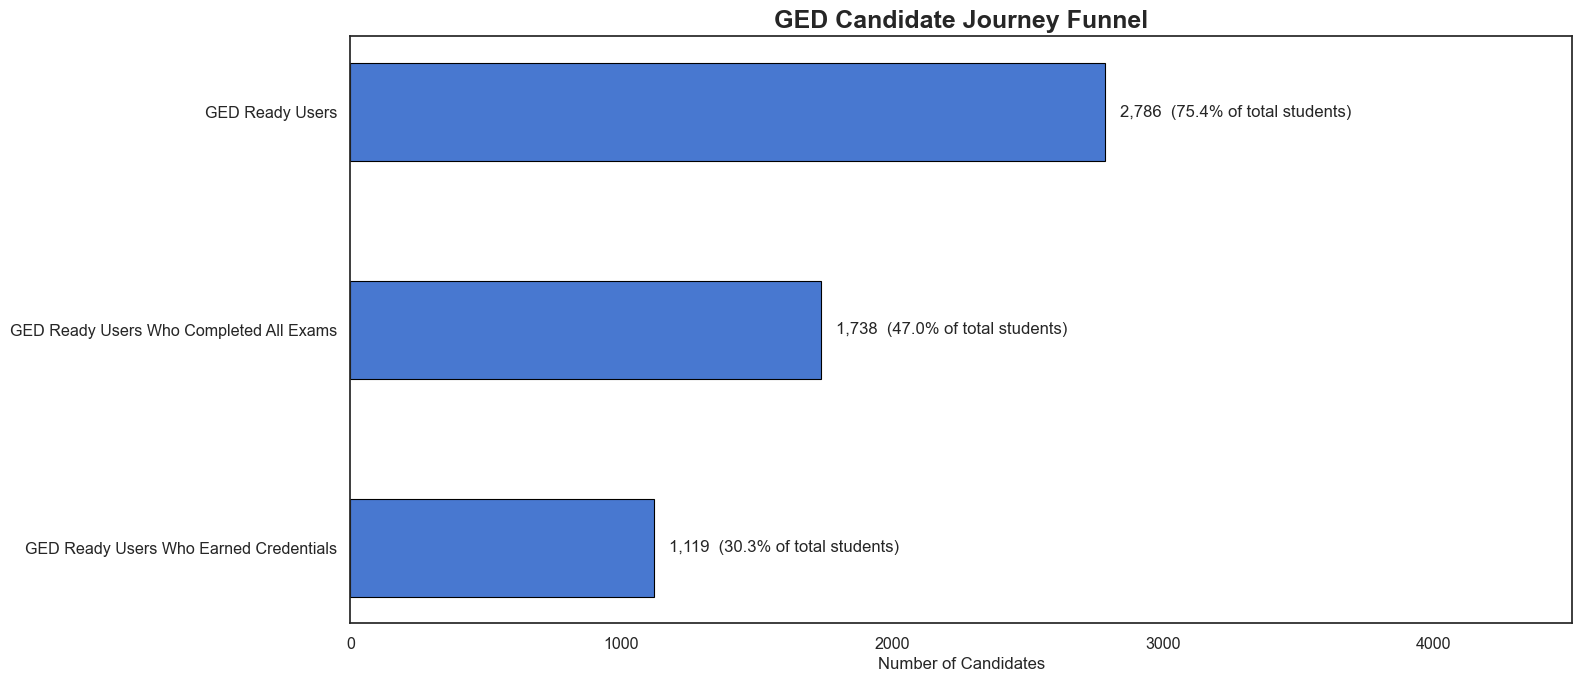

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Apply your theme + palette
sns.set_theme(style="white", palette="muted", font_scale=1.05)
COLORS     = sns.color_palette("muted")

# Compute the two metrics

completed_all_from_ready = df[
    (df['used_ged_ready'] == 1) &
    df[['score_math','score_science','score_reasoning','score_social_studies']].notna().all(axis=1)
].shape[0]

credentialed_from_ready = df[(df['used_ged_ready'] == 1) & (df['credential_earned']==1)].shape[0]

# Labels + values
stages = [
    "GED Ready Users",
    "GED Ready Users Who Completed All Exams",
    "GED Ready Users Who Earned Credentials",
]

values = [total_ged_ready, completed_all_from_ready, credentialed_from_ready]

# Percentages relative to GED Ready population
percentages = [v / total_students * 100 for v in values]

stages = stages[::-1]
values = values[::-1]
percentages = percentages[::-1]

plt.figure(figsize=(16, 7))  # wider figure

bar_height = 0.45
bars = plt.barh(
    stages,
    values,
    height=bar_height,
    color=COLORS[0],
    edgecolor="black",
    linewidth=0.8
)

for i, (v, pct) in enumerate(zip(values, percentages)):
    label = f"{v:,}  ({pct:.1f}% of total students)"
    plt.text(
        v + total_students * 0.015,
        i,
        label,
        va='center',
        fontsize=12
    )

plt.title("GED Candidate Journey Funnel", fontsize=18, weight='bold')
plt.xlabel("Number of Candidates", fontsize=12)
plt.grid(False)
# Extend x-axis so labels fit inside the frame
plt.xlim(0, total_students * 1.22)

plt.tight_layout()  # no rect needed anymore
plt.show()

75.4% used GED Ready, but only 30.3% of total students who used it earned credentials. 

The clusters explain why : Cluster 1 (high performers, 0% GED Ready usage) earned credentials without it, while Cluster 2 (100% GED Ready usage, 100% credentialed) shows that when high-ability students use support tools, they still succeed. 

The GED Ready funnel's 30.3% credential rate looks modest overall because it's dragged down by Cluster 3, who used GED Ready heavily but still failed.

In [93]:
print(f"Dataset: {df.shape[0]:,} candidates  |  {df.shape[1]} columns")
print("\nPerformance summary:")
print(df[["avg_score", "pass_rate", "college_ready_rate",
          "avg_retakes", "credential_earned"]].describe().round(3))

Dataset: 3,698 candidates  |  46 columns

Performance summary:
       avg_score  pass_rate  college_ready_rate  avg_retakes  \
count   3624.000   3698.000            3698.000     3698.000   
mean     150.238      0.665               0.111        0.847   
std       10.921      0.366               0.231        1.080   
min      100.000      0.000               0.000        0.000   
25%      143.761      0.400               0.000        0.000   
50%      149.889      0.800               0.000        0.750   
75%      156.889      1.000               0.111        1.250   
max      195.000      1.000               1.000       18.500   

       credential_earned  
count           3698.000  
mean               0.415  
std                0.493  
min                0.000  
25%                0.000  
50%                0.000  
75%                1.000  
max                1.000  


In [94]:
PREP_COLS = {
    "used_ged_ready": "GED Ready",
    "has_prep_center": "Prep Center",
    "study_adult_ed_class": "Adult Ed Class",
    "study_books": "Books / Print",
    "study_online_video": "Online Video"
}


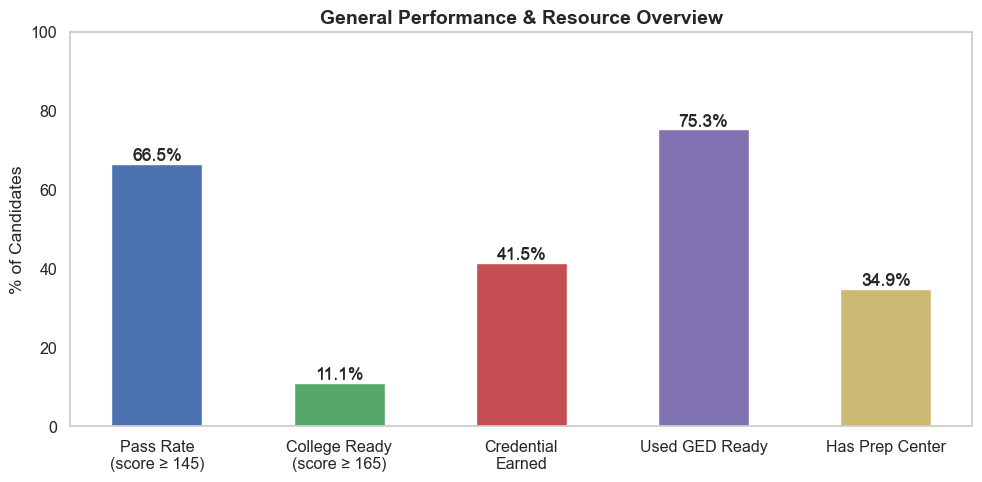

In [95]:
# 1. GENERAL PERFORMANCE OVERVIEW
metrics = {
    "Pass Rate\n(score ≥ 145)"        : df["pass_rate"].mean(),
    "College Ready\n(score ≥ 165)"    : df["college_ready_rate"].mean(),
    "Credential\nEarned"              : df["credential_earned"].mean(),
    "Used GED Ready"                  : df["used_ged_ready"].mean(),
    "Has Prep Center"                 : df["has_prep_center"].mean(),
}

percent_values = [v * 100 for v in metrics.values()]

plt.figure(figsize=(10, 5))
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974"]
bars = plt.bar(metrics.keys(), percent_values, color=colors, width = 0.5)

for bar, pct in zip(bars, percent_values):
    x = bar.get_x() + bar.get_width() / 2   # center of the bar
    y = pct + 1                              # slightly above the bar
    plt.text(x, y, f"{pct:.1f}%", ha="center")

ax = plt.gca()
ax.bar_label(bars, fmt="%.1f%%")
ax.set_ylim(0, 100)
ax.set_title("General Performance & Resource Overview", fontsize=14, fontweight="bold")
ax.set_ylabel("% of Candidates")
plt.tight_layout()
ax.grid(False)
plt.show()


# 1. Insights

Large pass-to-credential gap — 66.5% pass on average but only 41.5% earn the full credential, meaning 1 in 4 candidates passes subjects without completing the full GED.

College readiness is rare — Only 11.1% reach the college-ready threshold (≥165), so most passing candidates are barely clearing the minimum bar.

GED Ready dominates prep — 75.3% used GED Ready, nearly double the prep center rate (34.9%), making it the primary preparation mode.

Limited institutional support — Nearly 2 in 3 candidates had no prep center access, which may partly explain the low credential completion rate despite high GED Ready usage.

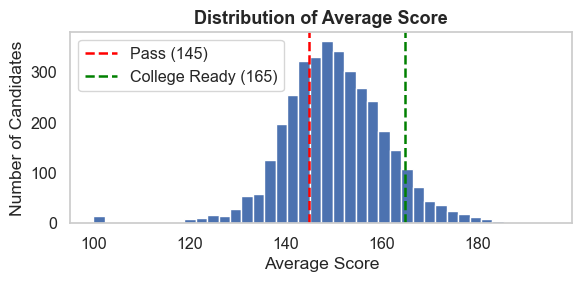

In [96]:
# 2. HISTOGRAM FOR AVG SCORE

plt.figure(figsize=(6, 3))

plt.hist(df["avg_score"].dropna(), bins=40, color="#4C72B0", edgecolor="white")
plt.axvline(145, color="red", linestyle="--", linewidth=1.8, label="Pass (145)")
plt.axvline(165, color="green", linestyle="--", linewidth=1.8, label="College Ready (165)")

plt.title("Distribution of Average Score", fontsize=13, fontweight="bold")
plt.xlabel("Average Score")
plt.ylabel("Number of Candidates")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

# 2. Insights

Most candidates cluster between 145–165 - the passing but not college-ready range, confirming that clearing the minimum bar is achievable for many but college-level proficiency is not.

A visible tail below 145 shows a meaningful minority of candidates are consistently scoring below the pass threshold, indicating a struggling segment that warrants targeted support.

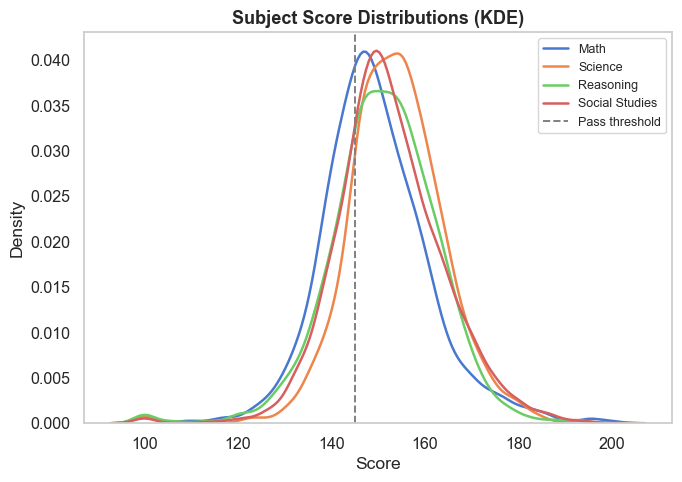

In [97]:
# 3. KDE FOR SUBJECT SCORES

plt.figure(figsize=(7, 5))

subject_cols = {
    "score_math": "Math",
    "score_science": "Science",
    "score_reasoning": "Reasoning",
    "score_social_studies": "Social Studies"
}

for col, label in subject_cols.items():
    sns.kdeplot(df[col].dropna(), label=label, linewidth=1.8)

plt.axvline(145, color="grey", linestyle="--", linewidth=1.4, label="Pass threshold")

plt.title("Subject Score Distributions (KDE)", fontsize=13, fontweight="bold")
plt.xlabel("Score")
plt.ylabel("Density")
plt.legend(fontsize=9)
plt.grid(False)

plt.tight_layout()
plt.show()

# 3. Insights

Math is the hardest subject — its curve peaks closest to the 145 pass threshold and has the largest left tail below 145, meaning more candidates fail Math than any other subject.

Science and Social Studies skew higher — both curves peak to the right of the pass line, indicating candidates generally perform better in these subjects.

Reasoning has the widest spread — its flatter, broader curve means candidate performance in Reasoning is the most variable — some score very high, others very low.

All subjects cluster near the pass threshold — no subject shows a distribution comfortably above 145, confirming that passing is a close call across the board for most candidates.

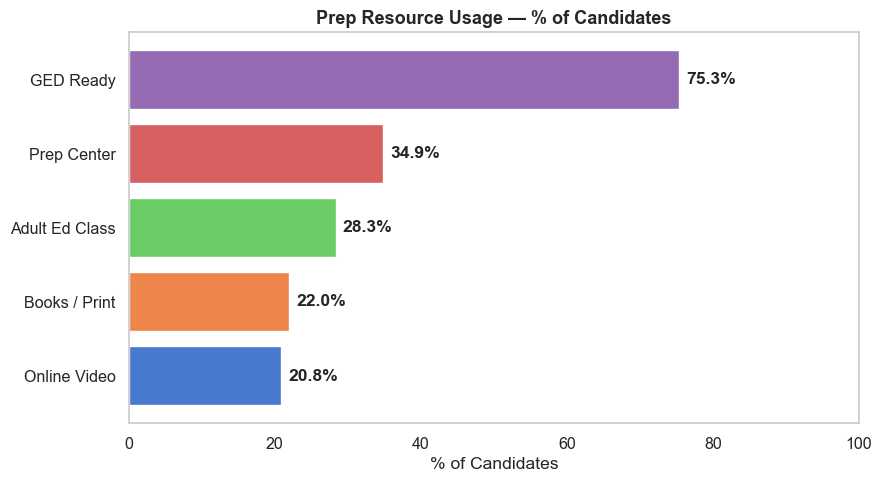

In [98]:
# PREP RESOURCE USAGE

# Calculate % usage for each resource
usage = {label: df[col].mean() * 100 for col, label in PREP_COLS.items()}
usage_s = pd.Series(usage).sort_values()

plt.figure(figsize=(9, 5))

bars = plt.barh(
    usage_s.index,
    usage_s.values,
    color=COLORS[:len(usage_s)],   # ← your muted palette
    edgecolor="white"
)

# Add labels to the right of each bar
for bar, val in zip(bars, usage_s.values):
    plt.text(val + 1, bar.get_y() + bar.get_height()/2,
             f"{val:.1f}%", va="center", fontweight="bold")

plt.xlim(0, 100)
plt.title("Prep Resource Usage — % of Candidates", fontsize=13, fontweight="bold")
plt.xlabel("% of Candidates")
plt.grid(False)
plt.tight_layout()
plt.show()

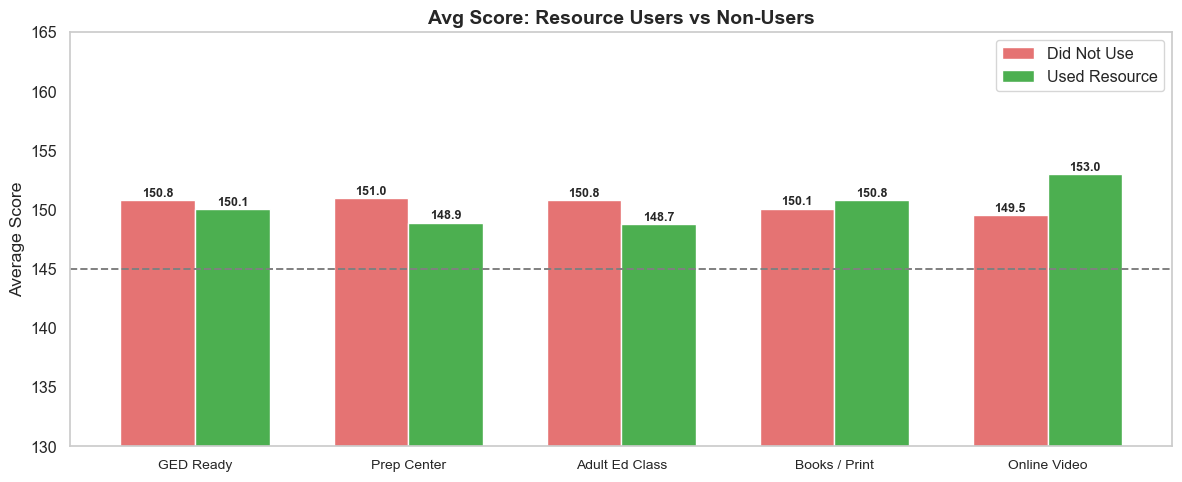

In [99]:
# 4.1 AVG SCORE BY PREP RESOURCE USAGE

plt.figure(figsize=(12, 5))

x = np.arange(len(PREP_COLS))
width = 0.35

# Average scores for users vs non-users
no_vals  = [df[df[col] == 0]["avg_score"].mean() for col in PREP_COLS]
yes_vals = [df[df[col] == 1]["avg_score"].mean() for col in PREP_COLS]

# Bars
bars_no  = plt.bar(x - width/2, no_vals,  width, label="Did Not Use",
                   color=FAIL_COLOR, edgecolor="white")

bars_yes = plt.bar(x + width/2, yes_vals, width, label="Used Resource",
                   color=PASS_COLOR, edgecolor="white")

# Add labels above bars
for bar in list(bars_no) + list(bars_yes):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f"{bar.get_height():.1f}",
             ha="center", fontsize=9, fontweight="bold")

# Pass threshold line
plt.axhline(145, color="grey", linestyle="--", linewidth=1.4)

plt.xticks(x, PREP_COLS.values(), fontsize=10)
plt.ylabel("Average Score")
plt.ylim(130, 165)
plt.title("Avg Score: Resource Users vs Non-Users", fontsize=14, fontweight="bold")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

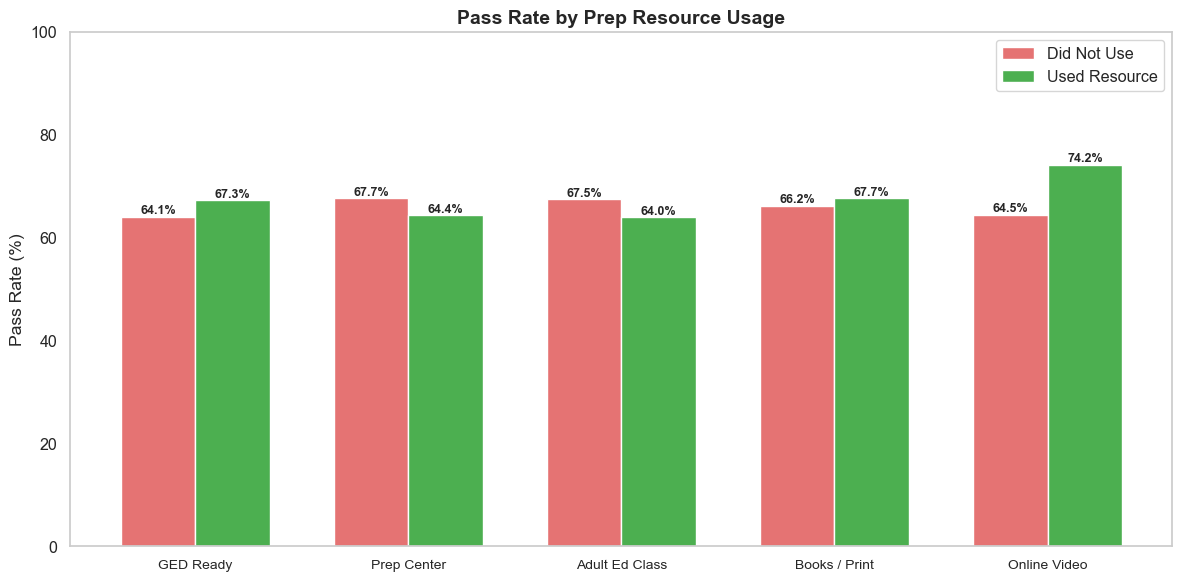

In [100]:
# 4.2. PASS RATE BY PREP RESOURCE USAGE

# Compute pass rates for users vs non-users
no_vals  = [df[df[col] == 0]["pass_rate"].mean() * 100 for col in PREP_COLS]
yes_vals = [df[df[col] == 1]["pass_rate"].mean() * 100 for col in PREP_COLS]

x = np.arange(len(PREP_COLS))
width = 0.35

plt.figure(figsize=(12, 6))

# Bars
bars_no = plt.bar(x - width/2, no_vals, width,
                  label="Did Not Use", color=FAIL_COLOR, edgecolor="white")

bars_yes = plt.bar(x + width/2, yes_vals, width,
                   label="Used Resource", color=PASS_COLOR, edgecolor="white")

# Add labels above bars
for bars in [bars_no, bars_yes]:
    for bar in bars:
        plt.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f"{bar.get_height():.1f}%",
                 ha="center", fontsize=9, fontweight="bold")

plt.xticks(x, PREP_COLS.values(), fontsize=10)
plt.ylabel("Pass Rate (%)")
plt.ylim(0, 100)
plt.title("Pass Rate by Prep Resource Usage", fontsize=14, fontweight="bold")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

# 4. Insights 

1. Online Video is the only resource with a clear positive signal
It's the standout across both charts - users score 3.5 points higher (153.0 vs 149.5) and have a 9.7 percentage point higher pass rate (74.2% vs 64.5%). Every other resource shows negligible or negative differences.

2. Prep Center and Adult Ed Class users actually score and pass less
Both charts show the same counterintuitive pattern - candidates who used these resources perform slightly worse than those who didn't. This likely reflects selection bias: struggling candidates are more likely to seek out structured support, so the resource didn't cause lower performance - it attracted lower performers.

3. GED Ready and Books show near-zero impact on avg score
The score differences are under 1 point in both cases, suggesting these resources alone don't meaningfully move the needle on raw performance.

4. Overall differences are narrow across all resources
All bars in both charts sit within a very tight band - roughly 148–153 for scores and 64–74% for pass rates. No single resource dramatically separates users from non-users, suggesting that resource usage alone is not the primary driver of performance and other factors (prior education, number of retakes, demographics) likely matter more.

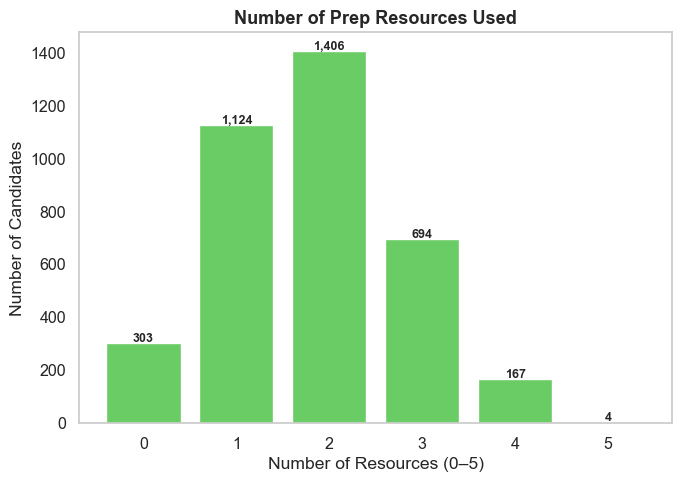

In [101]:
# 5.1 PREP RESOURCE COMBINATIONS

df["n_resources"] = df[list(PREP_COLS.keys())].sum(axis=1)

# --- Plot 1: Distribution of resource count ---
plt.figure(figsize=(7, 5))

counts = df["n_resources"].value_counts().sort_index()

plt.bar(counts.index, counts.values,
        color=COLORS[2], edgecolor="white")

# Labels above bars
for x_val, y_val in zip(counts.index, counts.values):
    plt.text(x_val, y_val + 5, f"{y_val:,}",
             ha="center", fontsize=9, fontweight="bold")

plt.title("Number of Prep Resources Used", fontsize=13, fontweight="bold")
plt.xlabel("Number of Resources (0–5)")
plt.ylabel("Number of Candidates")
plt.xticks(range(6))
plt.grid(False)
plt.tight_layout()
plt.show()

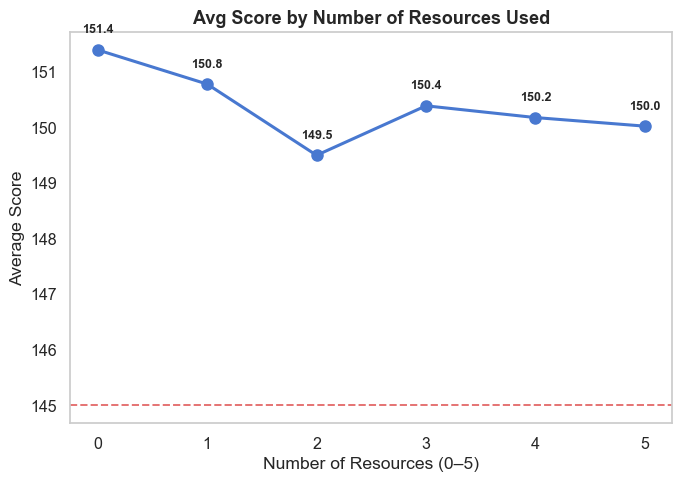

In [102]:
# 5.2 AVG SCORE BY NO. OF RESOURCES USED
plt.figure(figsize=(7, 5))

score_by_n = df.groupby("n_resources")["avg_score"].mean()

plt.plot(score_by_n.index, score_by_n.values,
         marker="o", linewidth=2.2,
         color=COLORS[0], markersize=8)

# Labels above points
for x_val, y_val in zip(score_by_n.index, score_by_n.values):
    plt.text(x_val, y_val + 0.3, f"{y_val:.1f}",
             ha="center", fontsize=9, fontweight="bold")

plt.axhline(145, color=FAIL_COLOR, linestyle="--", linewidth=1.4)

plt.title("Avg Score by Number of Resources Used", fontsize=13, fontweight="bold")
plt.xlabel("Number of Resources (0–5)")
plt.ylabel("Average Score")
plt.xticks(range(6))
plt.grid(False)
plt.tight_layout()
plt.show()

# 5. Insights

Most candidates use 1–2 resources. 2 resources is the most common (1,406 candidates), and very few use 4 or 5, suggesting multi-resource engagement drops off quickly.

Using more resources does not improve scores - average scores are virtually flat across all resource counts (149.5–151.4), with candidates using zero resources actually scoring highest at 151.4.

Quantity of resources is not the answer - the near-zero score variation across 0–5 resources reinforces that it's which resource candidates use (e.g. Online Video) that matters, not how many.

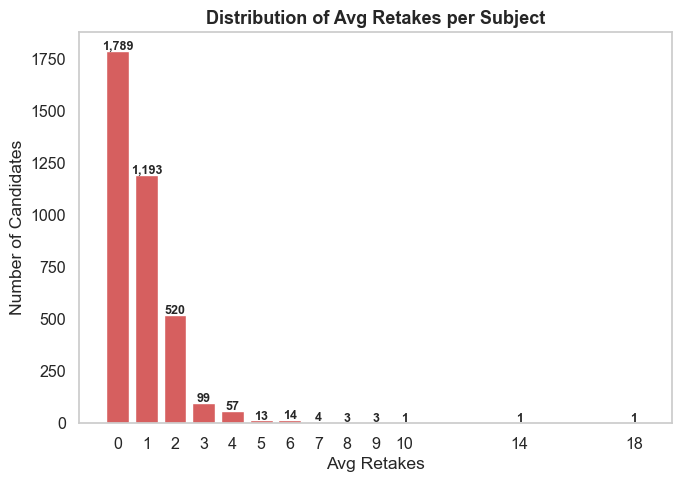

In [106]:
# --- Distribution of Avg Retakes (Single Plot) ---

plt.figure(figsize=(7, 5))

retake_counts = (
    df["avg_retakes"]
    .round(0)
    .astype(int)
    .value_counts()
    .sort_index()
)

plt.bar(
    retake_counts.index,
    retake_counts.values,
    color=COLORS[3],
    edgecolor="white"
)

# Labels above bars
for x_val, y_val in zip(retake_counts.index, retake_counts.values):
    plt.text(
        x_val,
        y_val + 5,
        f"{y_val:,}",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.title("Distribution of Avg Retakes per Subject", fontsize=13, fontweight="bold")
plt.xlabel("Avg Retakes")
plt.ylabel("Number of Candidates")
plt.xticks(retake_counts.index)
plt.grid(False)
plt.tight_layout()
plt.show()

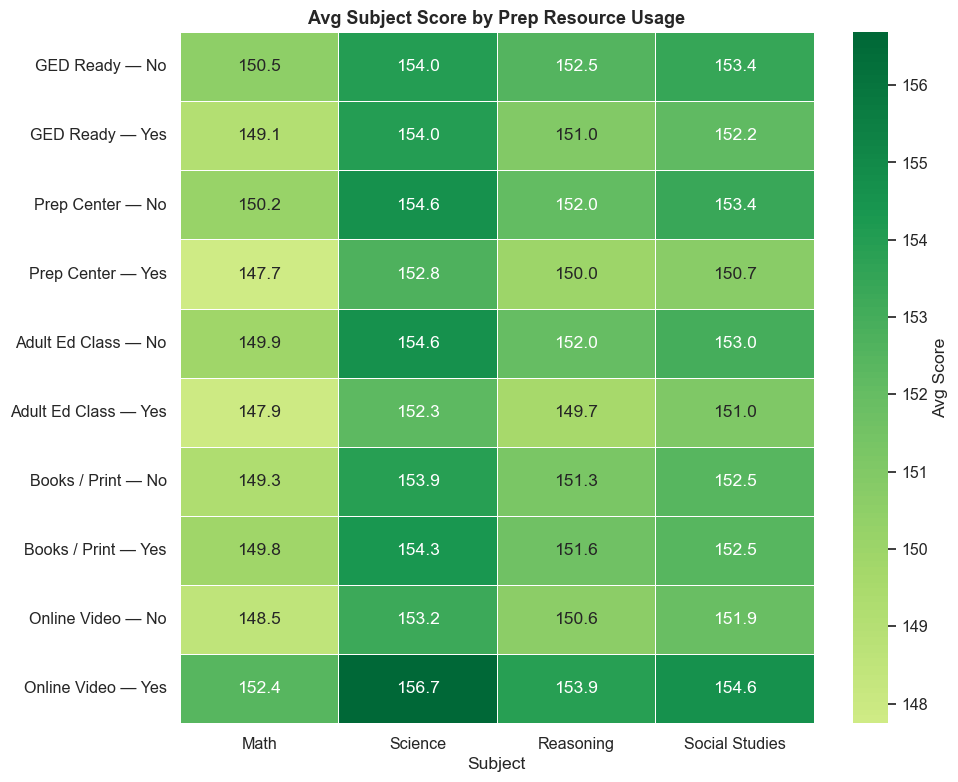

Saved: 09_subject_heatmap.png

✓ All plots saved.


In [107]:
# ── SECTION 10: SUBJECT SCORE PROFILES ───────────────────────────────────────
# Heatmap: avg subject score per prep resource group (used vs. not used)

subject_map = {
    "score_math"          : "Math",
    "score_science"       : "Science",
    "score_reasoning"     : "Reasoning",
    "score_social_studies": "Social Studies"
}

rows = []
for col, res_label in PREP_COLS.items():
    for used, grp_label in [(0, "No"), (1, "Yes")]:
        grp = df[df[col] == used]
        row = {"Resource": f"{res_label} — {grp_label}"}
        for s_col, s_label in subject_map.items():
            row[s_label] = grp[s_col].mean()
        rows.append(row)

heatmap_df = pd.DataFrame(rows).set_index("Resource")

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    heatmap_df,
    annot=True, fmt=".1f",
    cmap="RdYlGn",
    center=145,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Avg Score"},
    ax=ax
)
ax.set_title("Avg Subject Score by Prep Resource Usage",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Subject")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("09_subject_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 09_subject_heatmap.png")

print("\n✓ All plots saved.")